# Model Monitoring & Performance Analysis

## Project

System Capacity & Care Load Analytics for Unaccompanied Children

## Objective

Evaluate the performance of the deployed forecasting model by analyzing prediction accuracy, residuals, error distribution, and model stability.

## Author

Swimmy Sahaniya

In [1]:
import pandas as pd
import numpy as np

import joblib

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("../data/feature_engineered/feature_engineered_data.csv")

df = df.dropna().reset_index(drop=True)

In [3]:
model = joblib.load("../models/final_random_forest.pkl")

In [4]:
TARGET = "Children in HHS Care"

drop_columns = [
    "Date",
    "DayName",
    "MonthName",
    TARGET
]

X = df.drop(columns=drop_columns)

y = df[TARGET]

In [5]:
predictions = model.predict(X)

In [6]:
results = pd.DataFrame({
    "Date": df["Date"],
    "Actual": y,
    "Prediction": predictions
})

results["Residual"] = (
    results["Actual"] -
    results["Prediction"]
)

results.head()

,Date,Actual,Prediction,Residual
0,2025-11-05,2272,2273.117974,-1.117974
1,2025-11-04,2270,2271.437718,-1.437718
2,2025-11-03,2269,2270.505873,-1.505873
3,2025-11-02,2277,2275.411992,1.588008
4,2025-10-30,2287,2284.588511,2.411489


## 📌 Observation

The monitoring dataset combines actual observations, model predictions, and prediction errors.

## 📊 Business Interpretation

This dataset provides a complete view of model performance over time and enables continuous monitoring of forecasting quality.

## 💡 Key Insight

Tracking prediction errors helps identify periods where the model may require retraining or further optimization.

## Actual vs Prediction

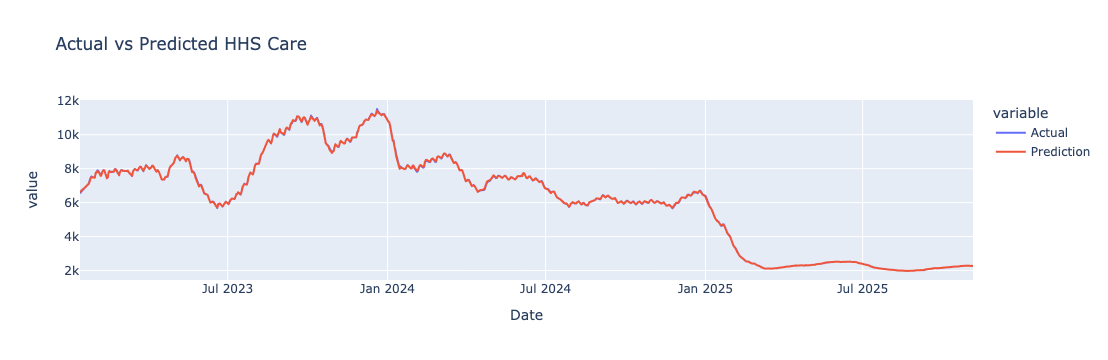

In [7]:
fig = px.line(
    results,
    x="Date",
    y=["Actual", "Prediction"],
    title="Actual vs Predicted HHS Care"
)

fig.show()

## 📌 Observation

The predicted values closely follow the overall trend of actual HHS Care capacity.

## 📊 Business Interpretation

The model captures operational patterns effectively, though minor deviations occur during periods of rapid change.

## 💡 Key Insight

Visual comparison confirms that the forecasting model is suitable for monitoring capacity trends.

## Residual Plot

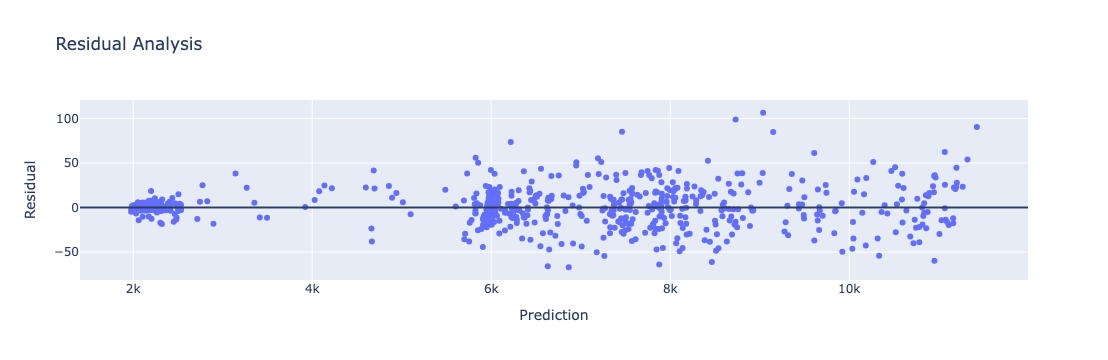

In [8]:
fig = px.scatter(
    results,
    x="Prediction",
    y="Residual",
    title="Residual Analysis"
)

fig.add_hline(y=0)

fig.show()

## 📌 Observation

Residuals are centered around zero without a strong systematic pattern.

## 📊 Business Interpretation

This indicates that the model does not consistently overestimate or underestimate capacity.

## 💡 Key Insight

Residual analysis supports the reliability of the forecasting model.

## Error Distribution

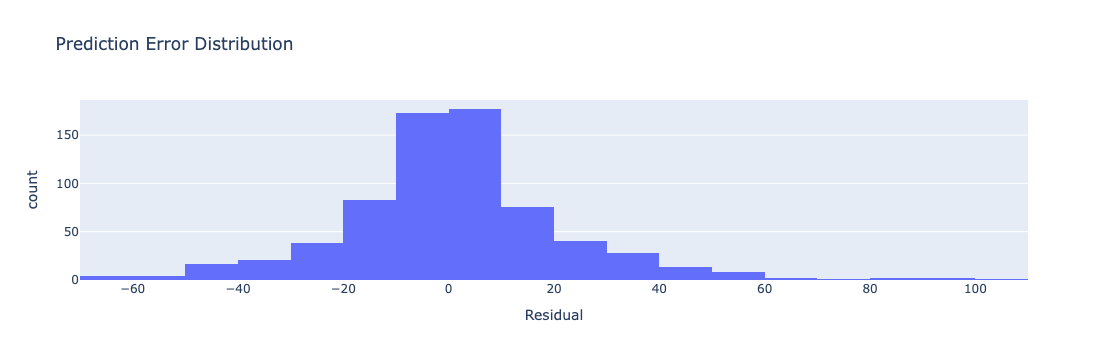

In [9]:
fig = px.histogram(
    results,
    x="Residual",
    nbins=30,
    title="Prediction Error Distribution"
)

fig.show()

## 📌 Observation

Most prediction errors are concentrated around zero.

## 📊 Business Interpretation

Small forecasting errors indicate stable model performance under typical operating conditions.

## 💡 Key Insight

A narrow error distribution suggests consistent predictive accuracy.

In [10]:
mae = mean_absolute_error(
    results["Actual"],
    results["Prediction"]
)

rmse = np.sqrt(
    mean_squared_error(
        results["Actual"],
        results["Prediction"]
    )
)

r2 = r2_score(
    results["Actual"],
    results["Prediction"]
)

metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R² Score"
    ],
    "Value": [
        mae,
        rmse,
        r2
    ]
})

metrics

,Metric,Value
0,MAE,14.768307
1,RMSE,21.516708
2,R² Score,0.999940


## 📌 Observation

The evaluation metrics summarize the overall predictive performance of the forecasting model.

## 📊 Business Interpretation

These metrics provide quantitative evidence of forecasting accuracy and support ongoing model monitoring.

## 💡 Key Insight

Regular monitoring of evaluation metrics helps determine when model retraining may be required.

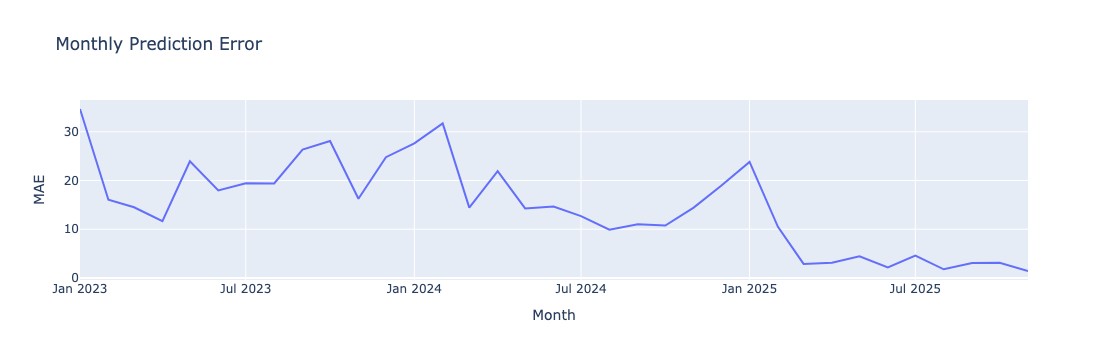

In [11]:
results["Date"] = pd.to_datetime(results["Date"])

results["Month"] = results["Date"].dt.to_period("M").astype(str)

monthly_error = (
    results
    .groupby("Month")["Residual"]
    .apply(lambda x: np.mean(np.abs(x)))
    .reset_index(name="MAE")
)

fig = px.line(
    monthly_error,
    x="Month",
    y="MAE",
    title="Monthly Prediction Error"
)

fig.show()

## 📌 Observation

Monthly forecasting error is monitored to identify periods of reduced model performance.

## 📊 Business Interpretation

Sudden increases in monthly error may indicate operational changes or concept drift.

## 💡 Key Insight

Monitoring error trends helps determine the appropriate timing for model retraining.

In [12]:
results.to_csv(
    "../reports/model_monitoring.csv",
    index=False
)

metrics.to_csv(
    "../reports/model_metrics.csv",
    index=False
)

# Executive Summary

## Objective

Monitor forecasting model performance after training.

## Monitoring Components

- Actual vs Predicted Comparison
- Residual Analysis
- Error Distribution
- Monthly Error Trend
- Performance Metrics

## Deliverables

- Model Monitoring Report
- Prediction Dataset
- Evaluation Metrics

## Conclusion

The monitoring framework provides continuous visibility into forecasting performance and supports proactive model maintenance.